In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


### Data loading

Load each dataset and understand what it contains

customer_data.csv

In [4]:
customers_df = pd.read_csv("customer_data.csv")
display(customers_df.describe().round(2))
# display(customers_df.head())
# quantiles = customers_df["total_amount"].quantile(
#     [0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
# )
# display(quantiles)


,customer_id,n_country,n_transactions,total_amount,n_counterparts,days_active,pos_perc,ecom_perc,cat_cash,cat_communication,cat_education,cat_entertainment,cat_fitness,cat_general,cat_groceries,cat_health,cat_holidays,cat_hotel,cat_lebensmittel,cat_living,cat_restaurant,cat_restaurants,cat_salary,cat_savings,cat_shopping,cat_tax,cat_transport,cat_wellness,cur_aud,cur_chf,cur_eur,cur_gbp,cur_mxn,cur_thb,cur_usd,country_ch,country_de,country_fr,country_gb,country_ie,country_it,country_us
count,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00
mean,2787.50,5.20,237.22,10799.02,76.57,398.96,0.60,0.40,1285.99,443.48,5.63,787.96,0.02,279.23,1872.93,280.86,1171.80,0.23,0.20,81.96,0.82,1440.53,0.73,249.78,1996.13,56.09,835.79,8.96,28.55,7863.18,1983.22,80.65,28.23,21.52,407.26,166.85,9.56,4.33,6.84,7.08,4.84,7.41
std,1609.80,4.92,440.77,22902.37,124.45,339.24,0.37,0.37,5405.95,1561.06,217.78,5526.95,1.13,1900.78,4877.57,901.26,4048.26,15.84,14.69,574.10,20.90,3894.57,23.11,2056.39,5835.03,302.91,2116.31,200.69,494.44,17737.01,5956.07,561.63,624.75,358.00,2061.21,347.99,36.01,21.86,26.76,26.34,21.93,31.61
min,0.00,1.00,1.00,0.05,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1393.75,1.00,7.00,150.23,4.00,64.00,0.27,0.03,0.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,106.32,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2787.50,3.00,49.00,1864.72,22.00,339.00,0.71,0.29,0.00,7.00,0.00,19.00,0.00,0.00,144.00,0.00,0.00,0.00,0.00,0.00,0.00,92.50,0.00,0.00,166.00,0.00,54.00,0.00,0.00,1052.92,49.24,0.00,0.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,4181.25,8.00,260.00,10734.86,92.00,696.00,0.97,0.73,353.25,225.00,0.00,296.00,0.00,75.00,1154.25,147.25,418.25,0.00,0.00,0.00,0.00,1036.00,0.00,0.00,1471.00,10.00,597.00,0.00,0.00,6782.69,1175.11,0.00,0.00,0.00,35.49,144.00,5.00,1.00,3.00,1.00,0.00,1.00
max,5575.00,33.00,5732.00,333261.57,1194.00,964.00,1.00,1.00,108786.00,40010.00,15254.00,247950.00,73.00,94262.00,86636.00,25003.00,100259.00,1176.00,1097.00,31114.00,1387.00,80175.00,1312.00,60810.00,190008.00,9658.00,28554.00,8743.00,20002.91,210670.03,99352.23,22209.08,29237.17,21420.09,50946.76,4362.00,1300.00,575.00,791.00,821.00,581.00,616.00


### Data cleanup

In [7]:
# Keep the raw import available and build a cleaned analysis dataframe.
customers_raw_df = customers_df.copy()

# Remove accidental whitespace and duplicate column labels.
customers_df.columns = customers_df.columns.str.strip()
customers_df = customers_df.loc[:, ~customers_df.columns.duplicated()]

# Remove columns whose complete values are exact duplicates of an earlier column.
exact_duplicate_columns = customers_df.columns[
    customers_df.T.duplicated(keep="first")
].tolist()
customers_clean_df = customers_df.drop(columns=exact_duplicate_columns).copy()

# Merge category columns that represent the same measure.
category_merges = {
    "cat_groceries": "cat_lebensmittel",
    "cat_restaurant": "cat_restaurants",
}
for target_column, source_column in category_merges.items():
    if {target_column, source_column}.issubset(customers_clean_df.columns):
        customers_clean_df[target_column] = (
            customers_clean_df[target_column].fillna(0)
            + customers_clean_df[source_column].fillna(0)
        )
        customers_clean_df = customers_clean_df.drop(columns=source_column)

missing_values = customers_clean_df.isna().sum()
duplicate_rows = int(customers_clean_df.duplicated().sum())
print("Removed exact duplicate columns:", exact_duplicate_columns)
print("Merged category columns:", category_merges)
print("Missing values:", int(missing_values.sum()))
print("Duplicate rows:", duplicate_rows)
print("Unique customer IDs:", customers_clean_df["customer_id"].is_unique)

display(customers_clean_df.head())

Removed exact duplicate columns: []
Merged category columns: {'cat_groceries': 'cat_lebensmittel', 'cat_restaurant': 'cat_restaurants'}
Missing values: 0
Duplicate rows: 0
Unique customer IDs: True


,customer_id,n_country,n_transactions,total_amount,n_counterparts,days_active,pos_perc,ecom_perc,cat_cash,cat_communication,cat_education,cat_entertainment,cat_fitness,cat_general,cat_groceries,cat_health,cat_holidays,cat_hotel,cat_living,cat_restaurant,cat_salary,cat_savings,cat_shopping,cat_tax,cat_transport,cat_wellness,cur_aud,cur_chf,cur_eur,cur_gbp,cur_mxn,cur_thb,cur_usd,country_ch,country_de,country_fr,country_gb,country_ie,country_it,country_us
0,0,11,197,21843.61,92,514,0.75,0.25,12620.0,1638.0,0.0,243.0,0.0,0.0,2021.0,0.0,619.0,0.0,0.0,392.0,0.0,3045.0,698.0,100.0,470.0,0.0,0.0,16147.62,5227.26,31.23,0.0,0.0,19.25,86.0,0.0,0.0,16.0,28.0,42.0,0.0
1,1,14,1736,104203.28,468,964,0.54,0.46,11233.0,2231.0,0.0,1956.0,0.0,1326.0,15503.0,3832.0,12673.0,0.0,1053.0,10935.0,0.0,19390.0,13468.0,267.0,10336.0,0.0,0.0,79513.95,23286.78,0.00,0.0,0.0,786.15,1325.0,9.0,1.0,5.0,146.0,96.0,4.0
2,2,31,3087,197449.56,629,964,0.21,0.79,15395.0,8950.0,0.0,105050.0,0.0,8964.0,16016.0,2072.0,3894.0,0.0,1510.0,10816.0,0.0,1421.0,18298.0,1003.0,4063.0,0.0,0.0,141381.46,28780.87,0.00,0.0,0.0,27091.00,1632.0,106.0,3.0,93.0,11.0,0.0,59.0
3,3,5,1412,49291.32,127,930,0.96,0.04,1450.0,291.0,0.0,209.0,0.0,0.0,37999.0,1260.0,132.0,0.0,0.0,491.0,26.0,0.0,5121.0,136.0,2175.0,0.0,0.0,42426.64,6864.68,0.00,0.0,0.0,0.00,1291.0,103.0,0.0,0.0,0.0,0.0,7.0
4,4,5,903,8224.79,183,525,0.95,0.05,0.0,0.0,0.0,243.0,0.0,0.0,1829.0,652.0,68.0,0.0,0.0,4784.0,0.0,0.0,575.0,0.0,74.0,0.0,0.0,7933.05,291.74,0.00,0.0,0.0,0.00,884.0,9.0,0.0,0.0,0.0,8.0,0.0


In [10]:
clean_csv_path = "customer_data_clean.csv"
customers_clean_df.to_csv(clean_csv_path, index=False)

print(f"Exported {customers_clean_df.shape[0]} rows and {customers_clean_df.shape[1]} columns to {clean_csv_path}")

Exported 5576 rows and 40 columns to customer_data_clean.csv


customer_data_labels.csv

In [11]:
customers_labeled_df = pd.read_csv("customer_data_labels.csv")
display(customers_labeled_df.head())
labeled_counts = customers_labeled_df["churned"].value_counts(dropna=False)
display(labeled_counts)
print("NA:", labeled_counts.get(np.nan, 0))

,customer_id,churned
0,4683,True
1,4514,False
2,619,True
3,1995,True
4,2361,False


churned
True     2140
False    1763
Name: count, dtype: int64

NA: 0


### Customer analysis - churned vs active

Use the churned/retained labels to form the 2 groups of customers

In [13]:
customers_merged_df = customers_clean_df.merge(customers_labeled_df, on="customer_id", how="inner")
customers_merged_df["segment"] = customers_merged_df["churned"].map({
    True: "Churned",
    False: "Active"
})
numeric_cols = customers_merged_df.select_dtypes(include="number").columns.drop(
    "customer_id",
    errors="ignore"
)
display(customers_merged_df.groupby("segment")[numeric_cols].describe().round(2))

n_country                                        n_transactions  \
            count  mean   std  min  25%  50%   75%   max          count   
segment                                                                   
Active     1763.0  7.69  5.35  1.0  3.0  7.0  11.0  33.0         1763.0   
Churned    2140.0  3.08  3.28  1.0  1.0  2.0   4.0  24.0         2140.0   

                                                         total_amount  \
           mean     std  min   25%    50%    75%     max        count   
segment                                                                 
Active   418.05  544.03  1.0  59.0  205.0  555.0  4180.0       1763.0   
Churned   78.29  198.24  1.0   3.0   10.0   54.0  2524.0       2140.0   

                                                                          \
             mean       std   min      25%      50%       75%        max   
segment                                                                    
Active   19068.39  29892.90  2.00  2225.05  8093.73  23065.29  317171.31   
Churned   3697.40  10379.22  0.05    61.86   260.00   2236.51  165156.98   

        n_counterparts                                                  \
                 count    mean     std  min   25%   50%    75%     max   
segment                                                                  
Active          1763.0  134.01  153.91  1.0  25.0  75.0  188.0  1194.0   
Churned         2140.0   27.82   57.04  1.0   2.0   6.0   25.0   533.0   

        days_active                                                  pos_perc  \
              count    mean     std  min    25%    50%    75%    max    count   
segment                                                                         
Active       1763.0  594.10  314.63  1.0  330.5  626.0  915.5  964.0   1763.0   
Churned      2140.0  229.22  257.15  1.0   12.0  125.0  377.0  963.0   2140.0   

                                                ecom_perc                   \
         mean   std  min   25%   50%   75%  max     count  mean   std  min   
segment                                                                      
Active   0.64  0.31  0.0  0.44  0.71  0.91  1.0    1763.0  0.36  0.31  0.0   
Churned  0.58  0.41  0.0  0.07  0.72  1.00  1.0    2140.0  0.42  0.41  0.0   

                               cat_cash                                    \
          25%   50%   75%  max    count     mean      std  min  25%   50%   
segment                                                                     
Active   0.09  0.29  0.56  1.0   1763.0  1846.83  6790.48  0.0  0.0  25.0   
Churned  0.00  0.28  0.93  1.0   2140.0   741.78  3661.57  0.0  0.0   0.0   

                          cat_communication                                   \
            75%       max             count    mean      std  min  25%   50%   
segment                                                                        
Active   1000.0  108786.0            1763.0  724.67  1932.68  0.0  0.0  97.0   
Churned    56.5   76958.0            2140.0  204.91  1327.14  0.0  0.0   0.0   

                        cat_education                                     \
           75%      max         count   mean     std  min  25%  50%  75%   
segment                                                                    
Active   611.0  39783.0        1763.0  14.81  377.08  0.0  0.0  0.0  0.0   
Churned   28.0  40010.0        2140.0   2.29   79.76  0.0  0.0  0.0  0.0   

                 cat_entertainment                                             \
             max             count     mean      std  min   25%    50%    75%   
segment                                                                         
Active   15254.0            1763.0  1321.05  7964.68  0.0  10.0  177.0  792.5   
Churned   3628.0            2140.0   366.87  2683.15  0.0   0.0    0.0   44.0   

                  cat_fitness                                        \
              max       count  mean   std  min  25%  50%  75%   max   
s

In [ ]:
churned_customers_df = customers_merged_df[
    customers_merged_df["segment"] == "Churned"
].copy()
active_customers_df = customers_merged_df[
    customers_merged_df["segment"] == "Active"
].copy()

churned_customers_df.to_csv("customer_data_churned.csv", index=False)
active_customers_df.to_csv("customer_data_active.csv", index=False)

print(f"Exported {len(churned_customers_df)} churned customers to {churned_csv_path}")
print(f"Exported {len(active_customers_df)} active customers to {active_csv_path}")


Exported 2140 churned customers to customer_data_churned.csv
Exported 1763 active customers to customer_data_active.csv
Exported rows match merged dataframe: True


Plot the distribution for the total amount, number of transactions, active days and ecommerce vs in point of sale usage.

How to read it:
A box plot shows the distribution of a variable for each customer segment:

Line inside the box: median (50th percentile)
Bottom/top of box: 25th and 75th percentiles
Box height: middle 50% of observations
Whiskers: typical minimum and maximum values
Dots: outliers

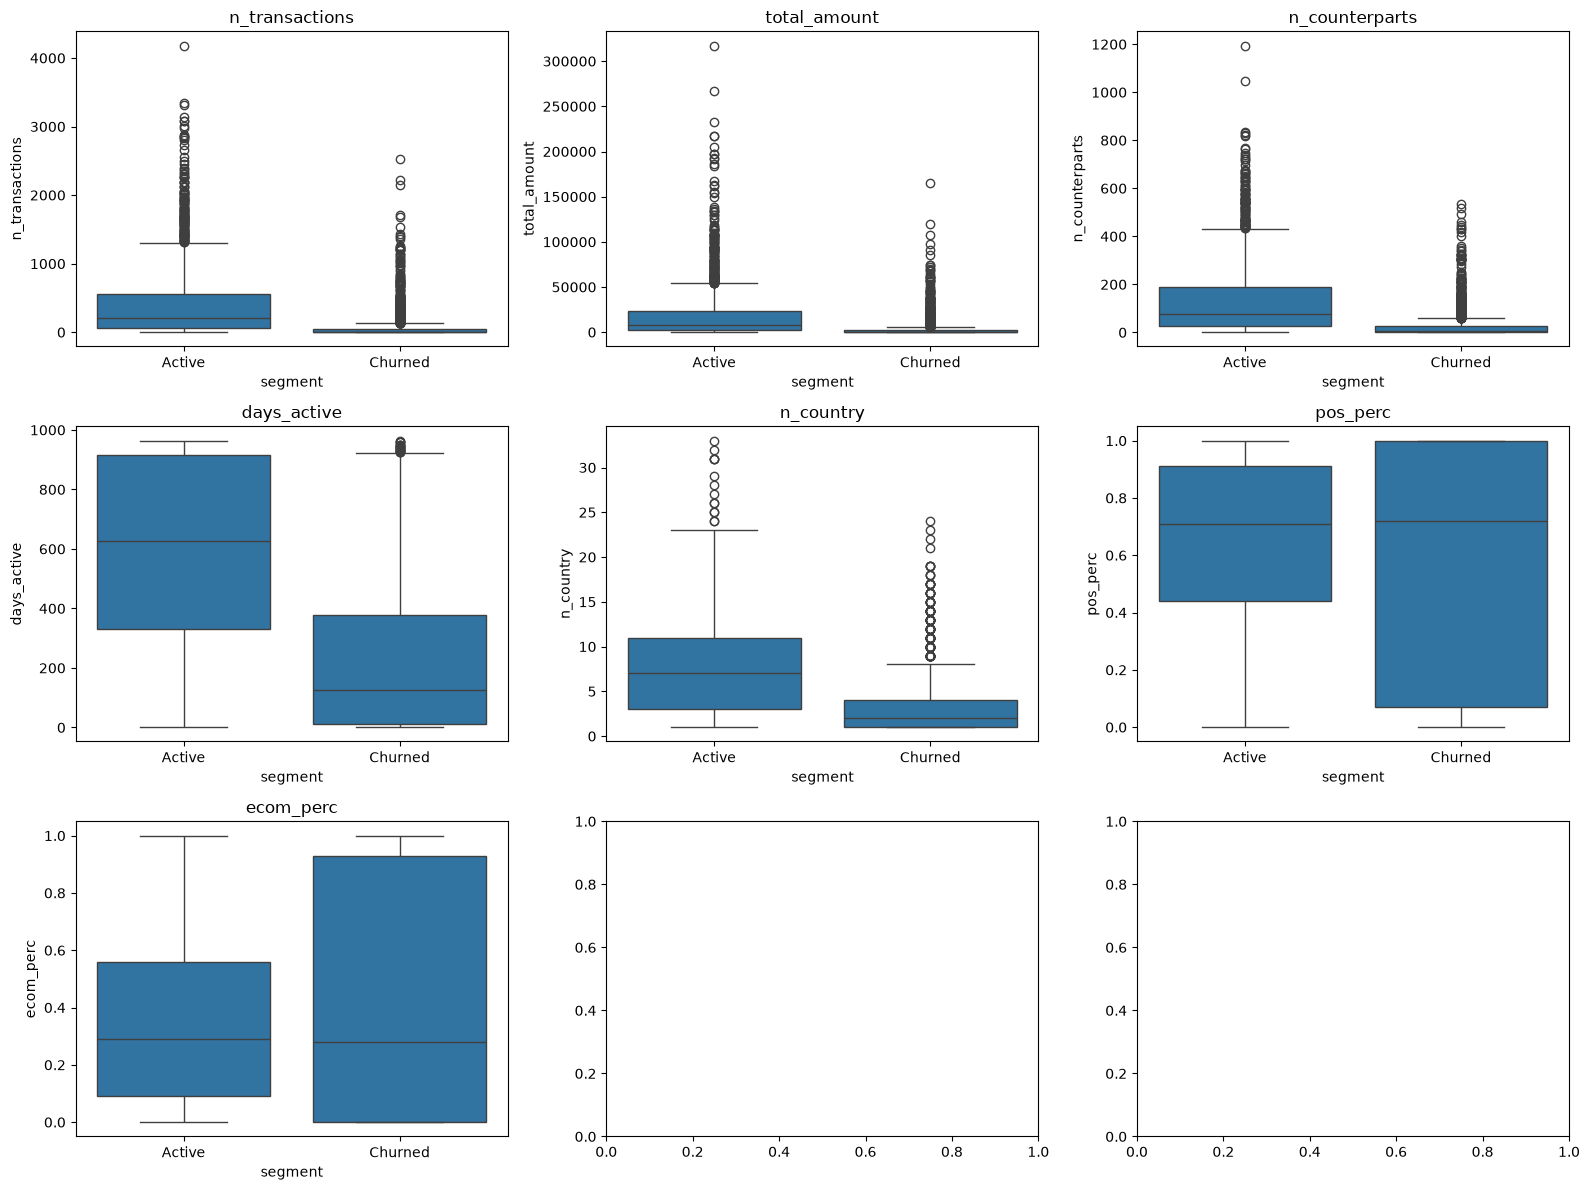

In [15]:
comparison_cols = [
    "n_transactions",
    "total_amount",
    "n_counterparts",
    "days_active",
    "n_country",
    "pos_perc",
    "ecom_perc"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flat

for axis, column in zip(axes, comparison_cols):
    sns.boxplot(
        data=customers_merged_df,
        x="segment",
        y=column,
        ax=axis
    )
    axis.set_title(column)

plt.tight_layout()
plt.show()

Interpretation:

- `total_amount`: Active customers generally spend considerably more. Both groups have many high-value outliers.
- `n_transactions`: Active customers make more transactions. Churned customers are concentrated at much lower values.
- `days_active`: Active customers are active for much longer. This appears to be the clearest difference.
- `pos_perc`: The medians are similar, but churned customers show greater variability.
- `ecom_perc`: The medians are also similar, although churned customers have a wider distribution.

In [16]:
category_cols = [
    column for column in customers_merged_df.columns
    if column.startswith("cat_")
]

category_medians = customers_merged_df.groupby("segment")[category_cols].median().T

display(category_medians.sort_values("Active", ascending=False))

segment,Active,Churned
cat_shopping,1066.0,11.0
cat_groceries,811.0,29.5
cat_restaurant,716.0,10.0
cat_transport,440.0,2.0
cat_holidays,234.0,0.0
cat_entertainment,177.0,0.0
cat_communication,97.0,0.0
cat_health,88.0,0.0
cat_general,28.0,0.0
cat_cash,25.0,0.0
